In [20]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt

from EOF_utils import eof_func, load_subsetdata, spatial_cube_subset, make_eof_ds

In [26]:
DS = xr.open_dataset('/glade/work/wchapman/b.e21.BHIST.f09_g17_Seasonal_Stochai_b050_025_1980.cam.h1.2010-10-13-00000.nc') 
DS_lat = DS["lat"]
DS_lon = DS["lon"]
DS_lev = DS["lev"]
delta_lat = float((DS_lat[1] - DS_lat[0]).values)
delta_lon = float((DS_lon[1] - DS_lon[0]).values)

lats_of_interest = [-75]#, -50, -25, 0, 25, 50, 75] #N
lons_of_interest = [0]#, 60, 120, 180, 240, 300] #E
levs_of_interest = [200]#, 500, 850] #hPa

# Specify which variable EOF you want to look at:
addvals = [0]#, 32, 64]
addval_names = ['U','V','T']
# Notes for addval:
# U = input_tensor[0:32] # 0
# V = input_tensor[32:64] # 32
# T = input_tensor[64:96] # 64
# Q = input_tensor[96:128] # 96
# TREFHT = input_tensor[129]
# PS = input_tensor[128]
# co2mr_3d = input_tensor[-1]
# ICEFRAC = input_tensor[-2]
# SST = input_tensor[-3]
# SOLIN = input_tensor[-4]
# LANDM_COSLAT = input_tensor[-5]
# z_norm = input_tensor[-6]

# grab +/- location of interet for horizontal portion of EOF
lat_range_of_interest = 5 #N +/-
lon_range_of_interest = 15 #E +/-
eof_numbers = np.arange(1, 4)
num_eofs = len(eof_numbers)

save_ddir = '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/EOF_analysis/predictU/'

In [27]:
## NOTE: Need to run this two more times once we have the IG for predicting V and T at all these lats, lons, and levs
no_skip = True #force it into else statement below with "True"

for iaddval, addval in enumerate(addvals): # which attribution variable map we focus on (U, V, or T)
    addval_name = addval_names[iaddval]
    for lat_of_interest in lats_of_interest: # predicted lat (U)
        for lon_of_interest in lons_of_interest: # predicted lon (U)
            for lev_of_interest in levs_of_interest: # predicted level (U)
                JJA_finame = 'EOF1-3_JJA_'+addval_name+'_'+str(lat_of_interest)+'x'+str(lon_of_interest)+'_'+str(lev_of_interest)+'hPa.nc'
                DJF_finame = 'EOF1-3_DJF_'+addval_name+'_'+str(lat_of_interest)+'x'+str(lon_of_interest)+'_'+str(lev_of_interest)+'hPa.nc'
                
                if os.path.exists(save_ddir+JJA_finame) and os.path.exists(save_ddir+DJF_finame) and (no_skip==False):
                    print(f"Files already exist - skipping")
                else:
                    print(f"Running")
                    print("Val: "+addval_name)
                    print("Latitude: "+str(lat_of_interest))
                    print("Longitude: "+str(lon_of_interest))
                    print("Level: "+str(lev_of_interest))
        
                    IG_allvars_JJA, IG_allvars_DJF, ilat_of_interest, ilon_of_interest = load_subsetdata(DS_lat, DS_lon, DS_lev,
                                                                                                         lat_of_interest,
                                                                                                         lon_of_interest,
                                                                                                         lev_of_interest)
                    
                    (IG_allvars_JJA_cubesubset,subset_lats,subset_lons) = spatial_cube_subset(IG_allvars_JJA,
                                                                    addval,
                                                                    DS_lat,
                                                                    DS_lon,
                                                                    lat_range_of_interest,
                                                                    lon_range_of_interest,
                                                                    ilat_of_interest,
                                                                    ilon_of_interest)
    
                    (IG_allvars_DJF_cubesubset,subset_lats_DJF,subset_lons_DJF) = spatial_cube_subset(IG_allvars_DJF,
                                                                                                        addval,
                                                                                                        DS_lat,
                                                                                                        DS_lon,
                                                                                                        lat_range_of_interest,
                                                                                                        lon_range_of_interest,
                                                                                                        ilat_of_interest,
                                                                                                        ilon_of_interest)
                    
                    
                    IG_allvars_JJA_flatsubset = np.reshape(IG_allvars_JJA_cubesubset,
                                                          (IG_allvars_JJA_cubesubset.shape[0],
                                                           IG_allvars_JJA_cubesubset.shape[1]*IG_allvars_JJA_cubesubset.shape[2]*IG_allvars_JJA_cubesubset.shape[3])
                                                          )
    
                    IG_allvars_DJF_flatsubset = np.reshape(IG_allvars_DJF_cubesubset,
                                                          (IG_allvars_DJF_cubesubset.shape[0],
                                                           IG_allvars_DJF_cubesubset.shape[1]*IG_allvars_DJF_cubesubset.shape[2]*IG_allvars_DJF_cubesubset.shape[3])
                                                          )
    
                    X_JJA = IG_allvars_JJA_flatsubset.copy()
                    X_DJF = IG_allvars_DJF_flatsubset.copy()
    
                    eof_JJA, pc_JJA, eigvals_JJA = eof_func(X_JJA, num_eofs=num_eofs)
                    eof_DJF, pc_DJF, eigvals_DJF = eof_func(X_DJF, num_eofs=num_eofs)
                    
                    eof_JJA_reshape = np.reshape(eof_JJA,
                                                 (IG_allvars_JJA_cubesubset.shape[1],
                                                  IG_allvars_JJA_cubesubset.shape[2],
                                                  IG_allvars_JJA_cubesubset.shape[3],
                                                  3))
    
                    eof_DJF_reshape = np.reshape(eof_DJF,
                                                 (IG_allvars_DJF_cubesubset.shape[1],
                                                  IG_allvars_DJF_cubesubset.shape[2],
                                                  IG_allvars_DJF_cubesubset.shape[3],
                                                  3))
    
                    eof_analysis_JJA_ds = make_eof_ds(eof_JJA_reshape,
                                                pc_JJA,
                                                eigvals_JJA,
                                                lats=subset_lats,
                                                lons=subset_lons,
                                                levs=DS_lev.values,
                                                eof_nums=eof_numbers,)
                    
                    eof_analysis_DJF_ds = make_eof_ds(eof_DJF_reshape,
                                                pc_DJF,
                                                eigvals_DJF,
                                                lats=subset_lats_DJF,
                                                lons=subset_lons_DJF,
                                                levs=DS_lev.values,
                                                eof_nums=eof_numbers,)
    
                    eof_analysis_JJA_ds.to_netcdf(save_ddir+JJA_finame)
                    eof_analysis_DJF_ds.to_netcdf(save_ddir+DJF_finame)
                    print('Saved')

Running
Val: U
Latitude: -75
Longitude: 0
Level: 200


PermissionError: [Errno 13] Permission denied: '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/EOF_analysis/predictU/EOF1-3_JJA_U_-75x0_200hPa.nc'

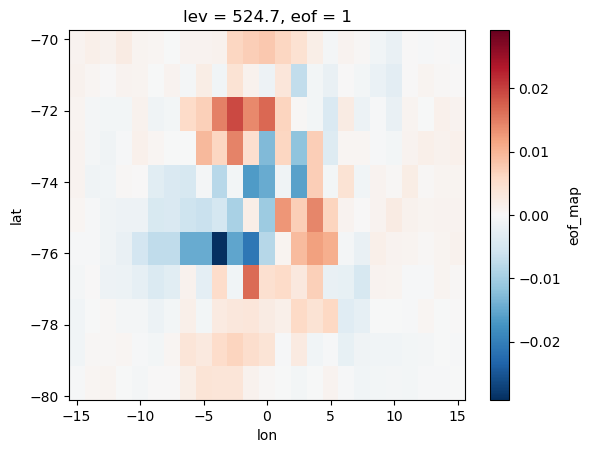

In [29]:
eof_analysis_JJA_ds['eof_map'].sel(lev=500, eof=1, method='nearest').plot()
plt.show()